In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [ ]:
RANDOM_SEED = 32
# Run 15: full (ranked + aggregated) feature set. BEST_NUM_FEATS comes from the FULL run's
# get_best_num_features(.005) in rfe.ipynb (=31, NOT the rank-only 17); source CSV is the _full trace.
BEST_NUM_FEATS = 31
SELECTED_RFE_CSV = 'rfe_features_kfolds_full.csv'
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    'learning_rate': [.03, .05, .1, .15, .2],
    'max_depth': [2, 3],
    'subsample': [.5, .7, .9],
    'min_child_weight': [10, 20, 50, 100],
    'gamma': [.5, 1, 5, 10, 100],
    'n_estimators': [10, 20,30, 40, 50],
    'early_stopping_rounds': [10, 20, 50],
    'importance_type': ['total_gain'],
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    f'../../../../../data/predict_games/model_features_in/{SELECTED_RFE_CSV}',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.61375	validation_1-auc:0.60971
[1]	validation_0-auc:0.62400	validation_1-auc:0.61992
[2]	validation_0-auc:0.62769	validation_1-auc:0.62653
[3]	validation_0-auc:0.63790	validation_1-auc:0.63110
[0]	validation_0-auc:0.62426	validation_1-auc:0.62052
[4]	validation_0-auc:0.64616	validation_1-auc:0.63831
[1]	validation_0-auc:0.65746	validation_1-auc:0.63481
[5]	validation_0-auc:0.65411	validation_1-auc:0.64404
[2]	validation_0-auc:0.67197	validation_1-auc:0.64542
[6]	validation_0-auc:0.65866	validation_1-auc:0.64462
[0]	validation_0-auc:0.63190	validation_1-auc:0.60151
[3]	validation_0-auc:0.67760	validation_1-auc:0.65352
[7]	validation_0-auc:0.66312	validation_1-auc:0.64565
[1]	validation_0-auc:0.65351	validation_1-auc:0.62114
[8]	validation_0-auc:0.66389	validation_1-auc:0.64516
[4]	validation_0-auc:0.68392	validation_1-auc:0.65184
[2]	validation_0-auc:0.67302	validation_1-auc:0.63101
[9]	validation_0-auc:0.66428	validation_1-auc:0.64596
[5]	validation_0-auc:0.68515

[3]	validation_0-auc:0.66678	validation_1-auc:0.64056
[23]	validation_0-auc:0.70326	validation_1-auc:0.65884
[12]	validation_0-auc:0.68140	validation_1-auc:0.64738
[7]	validation_0-auc:0.67661	validation_1-auc:0.65559
[24]	validation_0-auc:0.69195	validation_1-auc:0.65894
[23]	validation_0-auc:0.69020	validation_1-auc:0.65940
[31]	validation_0-auc:0.70614	validation_1-auc:0.65842
[23]	validation_0-auc:0.70266	validation_1-auc:0.65926
[21]	validation_0-auc:0.70441	validation_1-auc:0.65579
[17]	validation_0-auc:0.68589	validation_1-auc:0.65079
[28]	validation_0-auc:0.70551	validation_1-auc:0.65386
[4]	validation_0-auc:0.67621	validation_1-auc:0.65274
[24]	validation_0-auc:0.70362	validation_1-auc:0.65783
[13]	validation_0-auc:0.68308	validation_1-auc:0.64721
[8]	validation_0-auc:0.67942	validation_1-auc:0.65436
[25]	validation_0-auc:0.69293	validation_1-auc:0.65906
[24]	validation_0-auc:0.69007	validation_1-auc:0.65757
[11]	validation_0-auc:0.67804	validation_1-auc:0.65493
[32]	validatio

[8]	validation_0-auc:0.65981	validation_1-auc:0.64971
[3]	validation_0-auc:0.62777	validation_1-auc:0.62673
[39]	validation_0-auc:0.70033	validation_1-auc:0.66213
[4]	validation_0-auc:0.63614	validation_1-auc:0.63094
[5]	validation_0-auc:0.63892	validation_1-auc:0.63376
[5]	validation_0-auc:0.63860	validation_1-auc:0.63536
[0]	validation_0-auc:0.60031	validation_1-auc:0.59827
[5]	validation_0-auc:0.63640	validation_1-auc:0.63154
[6]	validation_0-auc:0.64243	validation_1-auc:0.63884
[6]	validation_0-auc:0.64119	validation_1-auc:0.63732
[1]	validation_0-auc:0.61524	validation_1-auc:0.61059
[4]	validation_0-auc:0.62777	validation_1-auc:0.62673
[9]	validation_0-auc:0.66602	validation_1-auc:0.65256
[6]	validation_0-auc:0.64508	validation_1-auc:0.63654
[7]	validation_0-auc:0.64243	validation_1-auc:0.63884
[7]	validation_0-auc:0.64119	validation_1-auc:0.63732
[2]	validation_0-auc:0.62284	validation_1-auc:0.61758
[5]	validation_0-auc:0.64057	validation_1-auc:0.64064
[7]	validation_0-auc:0.6450

[2]	validation_0-auc:0.65272	validation_1-auc:0.62625
[3]	validation_0-auc:0.62405	validation_1-auc:0.61656
[19]	validation_0-auc:0.69657	validation_1-auc:0.65561
[11]	validation_0-auc:0.68121	validation_1-auc:0.66422
[0]	validation_0-auc:0.61375	validation_1-auc:0.60971
[6]	validation_0-auc:0.66898	validation_1-auc:0.65685
[4]	validation_0-auc:0.66585	validation_1-auc:0.65192
[4]	validation_0-auc:0.63908	validation_1-auc:0.63220
[3]	validation_0-auc:0.65992	validation_1-auc:0.63720
[1]	validation_0-auc:0.63115	validation_1-auc:0.63126
[12]	validation_0-auc:0.68347	validation_1-auc:0.66574
[7]	validation_0-auc:0.66930	validation_1-auc:0.65993
[0]	validation_0-auc:0.62426	validation_1-auc:0.62052
[2]	validation_0-auc:0.65710	validation_1-auc:0.63888
[5]	validation_0-auc:0.67407	validation_1-auc:0.65876
[5]	validation_0-auc:0.64304	validation_1-auc:0.63453
[4]	validation_0-auc:0.66016	validation_1-auc:0.63852
[2]	validation_0-auc:0.63959	validation_1-auc:0.63150
[3]	validation_0-auc:0.65

[4]	validation_0-auc:0.67770	validation_1-auc:0.66237
[3]	validation_0-auc:0.67311	validation_1-auc:0.64137
[26]	validation_0-auc:0.70857	validation_1-auc:0.65289
[3]	validation_0-auc:0.63826	validation_1-auc:0.63146
[18]	validation_0-auc:0.68415	validation_1-auc:0.66215
[15]	validation_0-auc:0.69757	validation_1-auc:0.66103
[16]	validation_0-auc:0.68170	validation_1-auc:0.65905
[5]	validation_0-auc:0.68242	validation_1-auc:0.66038
[4]	validation_0-auc:0.67651	validation_1-auc:0.64627
[27]	validation_0-auc:0.70926	validation_1-auc:0.65275
[16]	validation_0-auc:0.70177	validation_1-auc:0.64955
[4]	validation_0-auc:0.64186	validation_1-auc:0.63449
[16]	validation_0-auc:0.69831	validation_1-auc:0.66068
[19]	validation_0-auc:0.68454	validation_1-auc:0.66125
[17]	validation_0-auc:0.68174	validation_1-auc:0.65934
[0]	validation_0-auc:0.56726	validation_1-auc:0.55249
[2]	validation_0-auc:0.64734	validation_1-auc:0.61775
[6]	validation_0-auc:0.68477	validation_1-auc:0.66217
[5]	validation_0-au

...

[36]	validation_0-auc:0.70341	validation_1-auc:0.65761


[37]	validation_0-auc:0.70334	validation_1-auc:0.65769


[38]	validation_0-auc:0.70370	validation_1-auc:0.65774


[39]	validation_0-auc:0.70370	validation_1-auc:0.65774




Best parameters found:  {'subsample': 0.7, 'n_estimators': 40, 'min_child_weight': 20, 'max_depth': 2, 'learning_rate': 0.15, 'importance_type': 'total_gain', 'gamma': 10, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  0.6834482337921767


Best Selected Features:  ['off_opp_success_rate_competitive_cumulative_average_rank', 'target_off_cumulative_avg_score_rank', 'off_target_success_rate_competitive_cumulative_average_rank', 'def_target_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'def_opp_sack_yards_cumulative_average_rank', 'opp_def_cumulative_avg_points_allowed_rank', 'off_opp_sack_rate_garbage_leading_cumulative_average_rank', 'target_def_cumulative_avg_points_allowed_rank', 'def_target_sack_rate_garbage_leading_cumulative_average_rank', 'off_opp_sack_yards_cumulative_average_rank', 'is_home_target', 'def_opp_fumble_lost_rate_competitive_cumulative_average_rank', 'def_target_yac_over_expected_competitive_cumulative_average_ra

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.10457768, 0.12088938, 0.10170326, 0.10965695, 0.12216778,
        0.03565979, 0.05596476, 0.0562851 , 0.09388685, 0.08866653,
        0.03798709, 0.03590918, 0.09100475, 0.08527346, 0.10940266,
        0.05995979, 0.05700879, 0.0595305 , 0.06103234, 0.040835  ,
        0.03810339, 0.05237727, 0.06979322, 0.08026638, 0.09363275,
        0.11355762, 0.0588182 , 0.05683079, 0.08070889, 0.08333292,
        0.07914338, 0.12981377, 0.06122327, 0.09704533, 0.03522687,
        0.0353837 , 0.05934906, 0.08037677, 0.03911786, 0.05604496,
        0.09215441, 0.11547899, 0.04628305, 0.05340834, 0.10185704,
        0.04159441, 0.03781509, 0.0590652 , 0.06940293, 0.11468577,
        0.07267785, 0.03931799, 0.12140741, 0.03571763, 0.09982848,
        0.06462393, 0.12785716, 0.04069324, 0.10148115, 0.04777112,
        0.08873258, 0.08339477, 0.03549371, 0.03840456, 0.06178617,
        0.07912045, 0.04761472, 0.06485338, 0.09941859, 0.12855039,
        0.07857471, 0.05840106,

<Axes: >

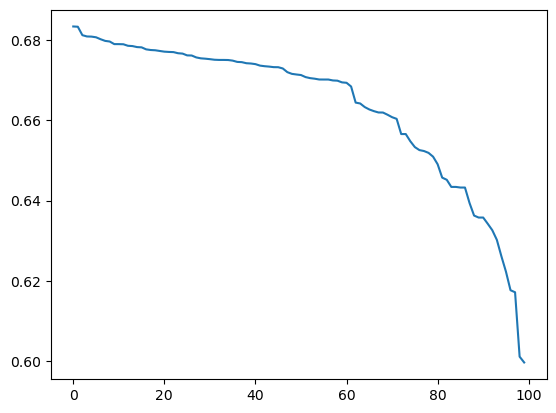

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.101614,0.005225,0.001898,0.000090,0.7,40,20,2,0.15,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.686229,0.684592,0.670249,0.677777,0.698394,0.683448,0.009368,1
1,0.121407,0.013127,0.003248,0.002599,0.5,50,50,2,0.15,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.680724,0.684895,0.671804,0.678477,0.701023,0.683385,0.009784,2
2,0.128550,0.011184,0.002545,0.001023,0.5,50,100,2,0.1,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.684468,0.680756,0.666202,0.679302,0.695664,0.681278,0.009472,3
3,0.129814,0.014109,0.002833,0.000978,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.678168,0.674750,0.670250,0.684484,0.697147,0.680960,0.009333,4
4,0.097045,0.006385,0.002101,0.000354,0.9,40,100,3,0.15,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.682363,0.682152,0.663966,0.680852,0.695271,0.680921,0.009970,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6323529411764706

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [ ]:
# Run 15: single overall hold-out AUROC, computed exactly like bart.ipynb, for a clean
# apples-to-apples comparison against the 0.705 champion.
overall_holdout_auroc = roc_auc_score(holdout_df['target_win'], holdout_df['preds'])
print(f'2024+2025 hold-out ROC-AUC (overall): {overall_holdout_auroc:.4f}  '
      f'[{BEST_NUM_FEATS} features, full set]')

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.224802
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.773443
2,2024_01_BAL_KC,1,KC,BAL,1,0.570354
3,2024_01_BAL_KC,1,BAL,KC,0,0.444486
4,2024_01_CAR_NO,1,CAR,NO,0,0.277129
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.554158
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.769794
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.214358
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.674992


week
1     0.820312
2     0.638672
3     0.538086
4     0.667969
5     0.465561
6     0.775268
7     0.823333
8     0.751486
9     0.736029
10    0.621173
11    0.665874
12    0.722908
13    0.707031
14    0.759945
15    0.787109
16    0.682617
17    0.684570
18    0.593750
dtype: float64

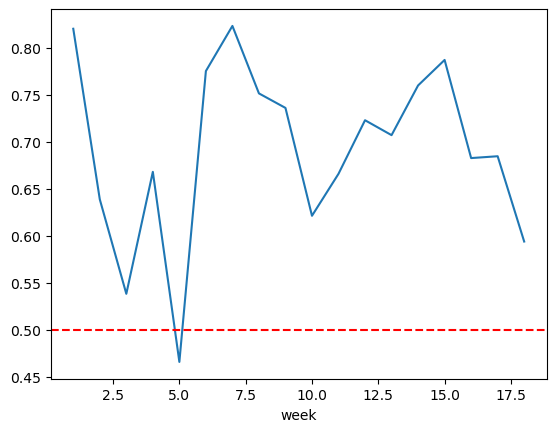

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.506410
2     0.440909
3     0.589844
4     0.633333
5     0.552083
6     0.752632
7     0.687500
8     0.583333
9     0.636842
10    0.566845
11    0.716346
12    0.578947
13    0.588745
14    0.564286
15    0.671498
16    0.749020
17    0.463203
18    0.666667
dtype: float64

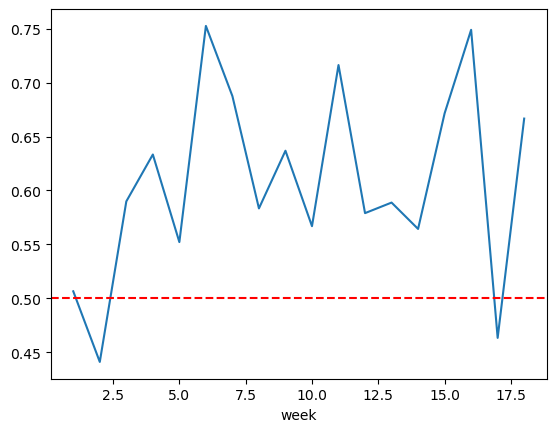

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [16]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2231  (lower is better; 0.25 = coin flip)
Log loss:    0.6365  (lower is better; punishes confident-and-wrong hardest)


In [17]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",219,0.543379,0.555328,0.011949
"(0.6, 0.7]",182,0.653846,0.644473,-0.009373
"(0.7, 0.8]",88,0.795455,0.737006,-0.058449
"(0.8, 0.9]",7,1.000000,0.823106,-0.176894


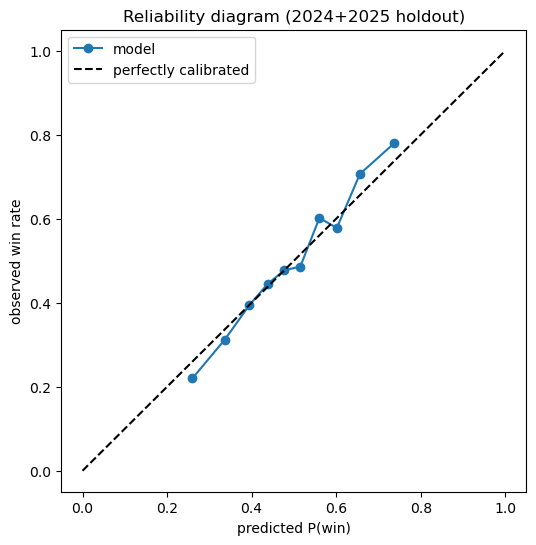

In [18]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [19]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.202


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-0.000755, 0.0783]",109,0.044005,0.504587
"(0.0783, 0.149]",109,0.114136,0.605505
"(0.149, 0.252]",108,0.196846,0.620370
"(0.252, 0.388]",109,0.312440,0.678899
"(0.388, 0.68]",109,0.468506,0.788991


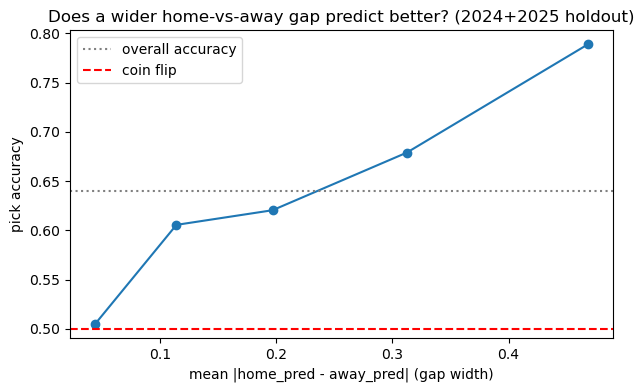

In [20]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()